In [1]:
import pandas as pd
from sklearn . linear_model import LinearRegression
from sklearn . metrics import mean_squared_error
import numpy as np
import matplotlib . pyplot as plt
from sklearn . preprocessing import PolynomialFeatures

In [3]:
train_df = pd.read_csv("energyefficient_train.csv")
test_df = pd.read_csv("energyefficient_test.csv")
val_df = pd.read_csv("energyefficient_val.csv")

In [29]:


X_train = train_df[["X1"]]
y_train = train_df ["Y"]

X_val = val_df[["X1"]]
y_val = val_df ["Y"]

X_test = test_df[["X1"]]
y_test = test_df ["Y"]

In [30]:
lin_reg = LinearRegression ()
lin_reg . fit ( X_train , y_train )
# Generate predictions
y_train_pred = lin_reg . predict ( X_train )
y_val_pred = lin_reg . predict ( X_val )
y_test_pred = lin_reg . predict ( X_test )
rmse_train = np . sqrt ( mean_squared_error ( y_train , y_train_pred ) )
rmse_val = np . sqrt ( mean_squared_error ( y_val , y_val_pred ) )
rmse_test = np . sqrt ( mean_squared_error ( y_test , y_test_pred ) )
print("Train RMSE : {rmse_train:.4f} | Val RMSE : {rmse_val:.4f}| Test RMSE : {rmse_test:.4f}".format(rmse_train=rmse_train, rmse_val=rmse_val, rmse_test=rmse_test))


Train RMSE : 7.9419 | Val RMSE : 8.1256| Test RMSE : 7.5179


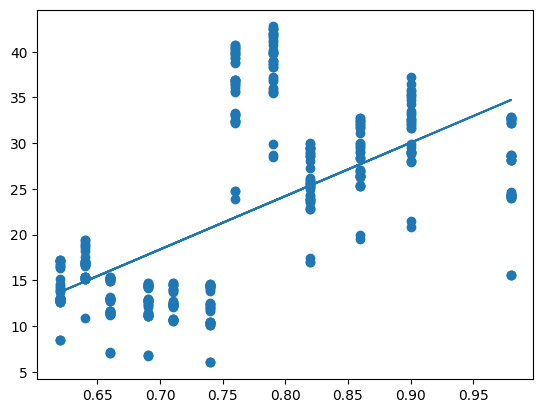

In [31]:
plt.scatter( X_train , y_train , label ="trining data")
plt.plot(X_train , y_train_pred)


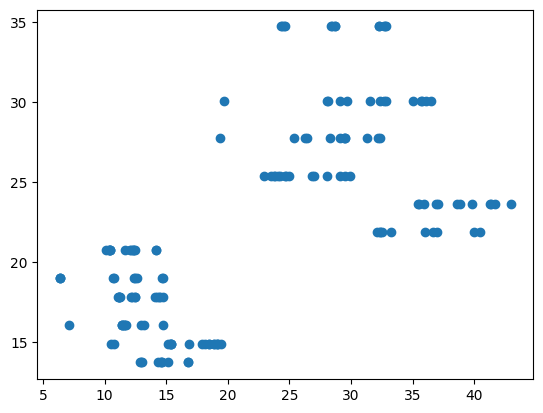

In [34]:
plt.scatter( y_test, y_test_pred , label ="training data")

In [ ]:
##polynomial

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


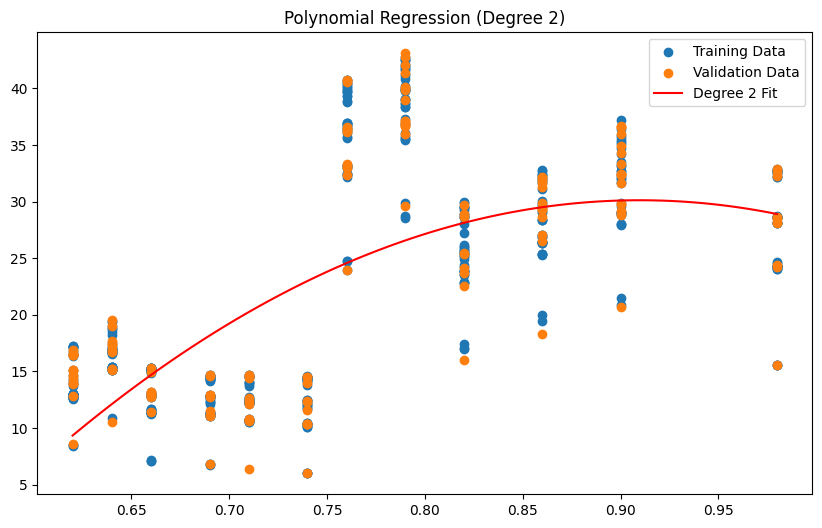

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


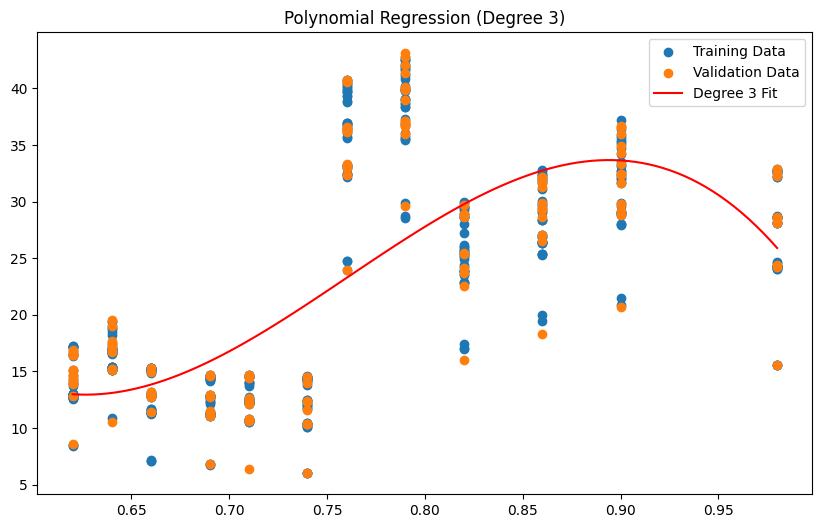

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


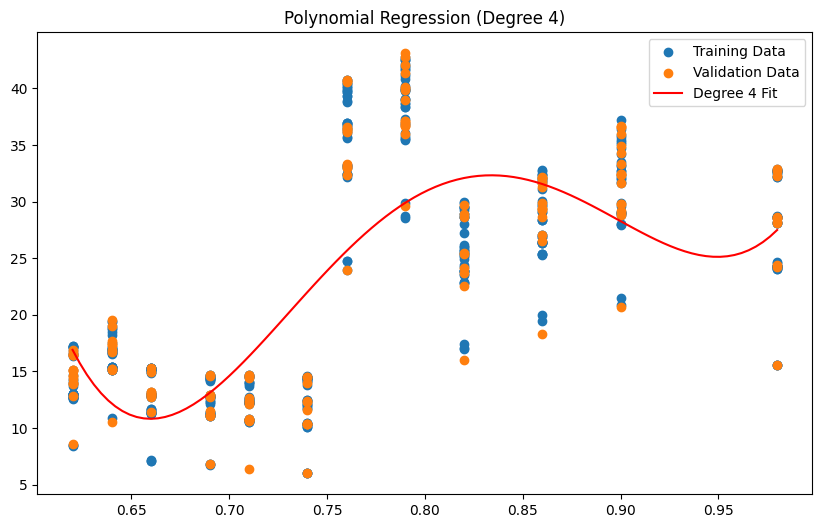

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


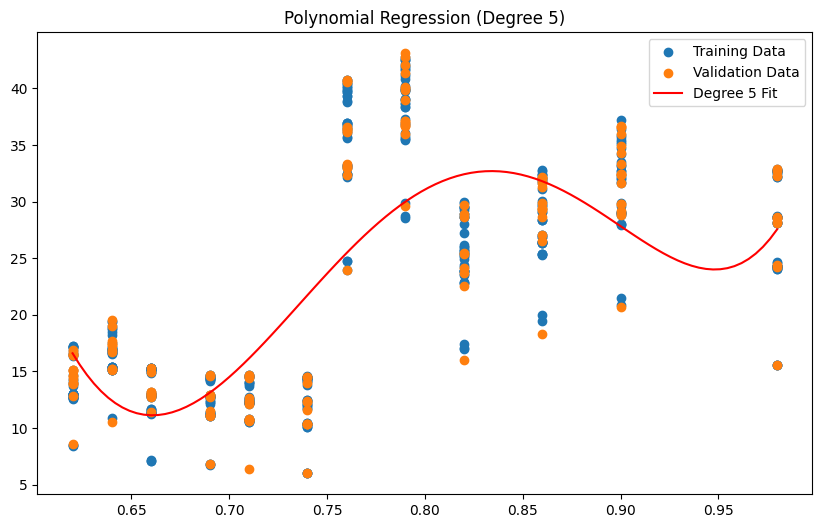

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


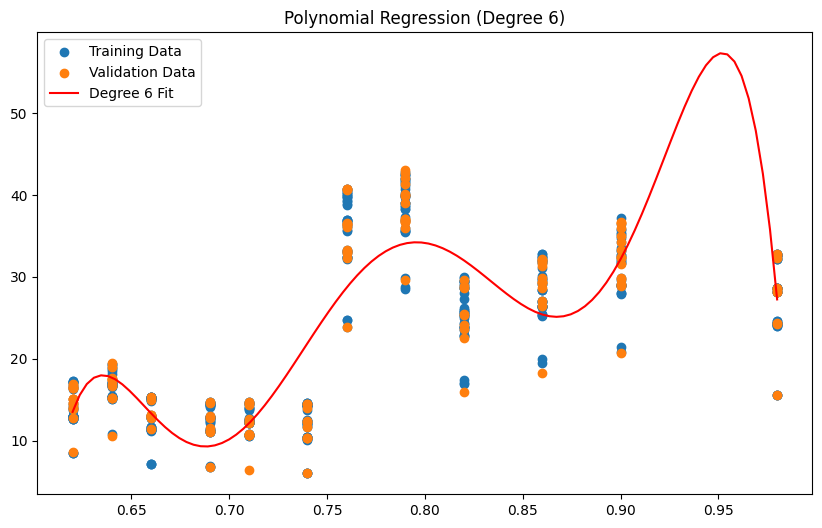

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


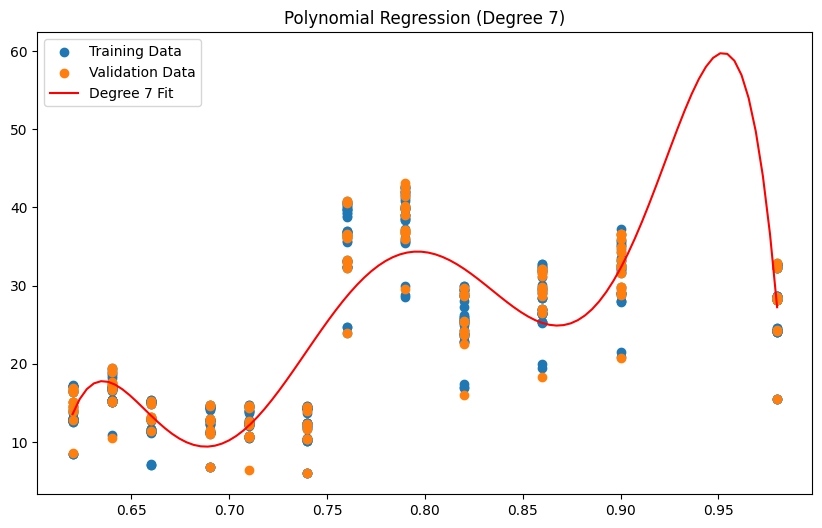

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


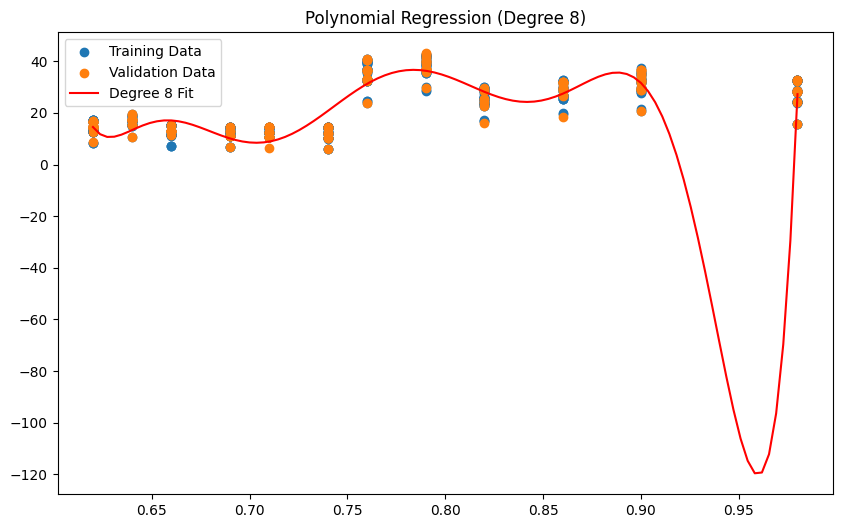

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


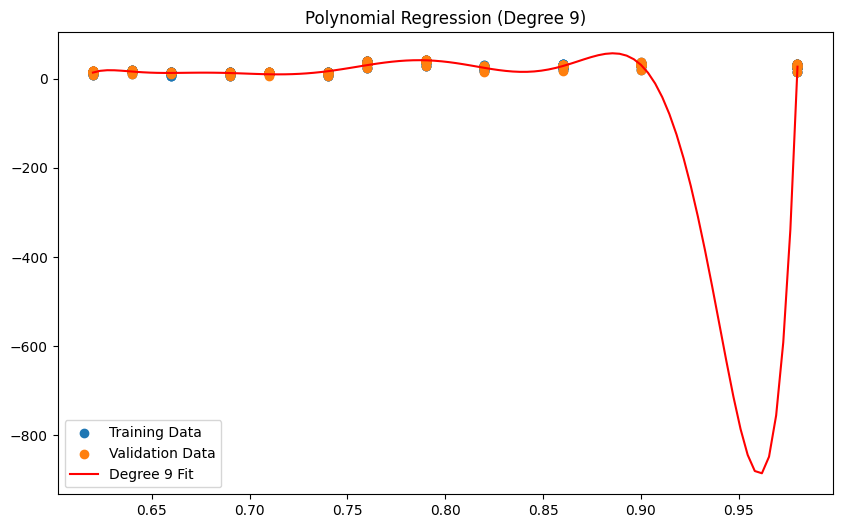

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


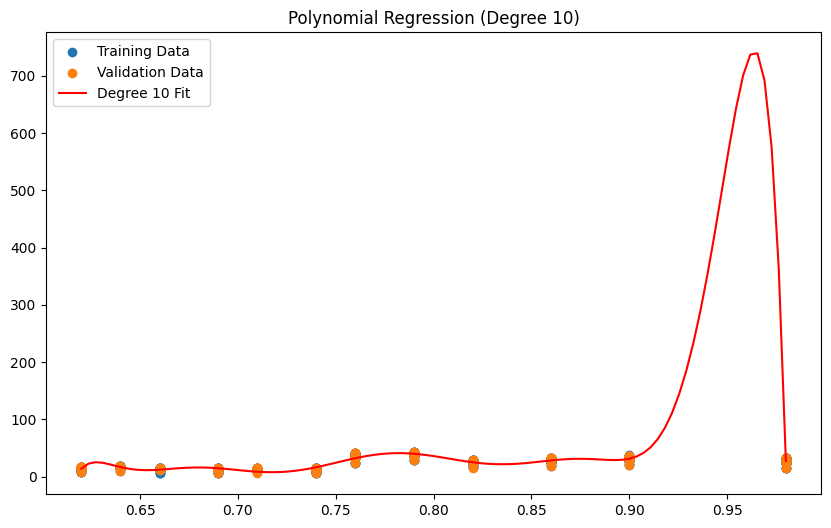

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


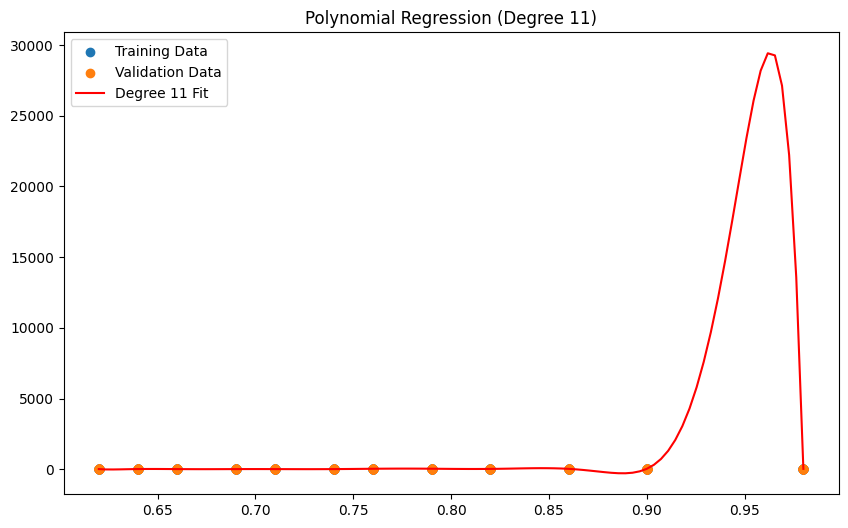

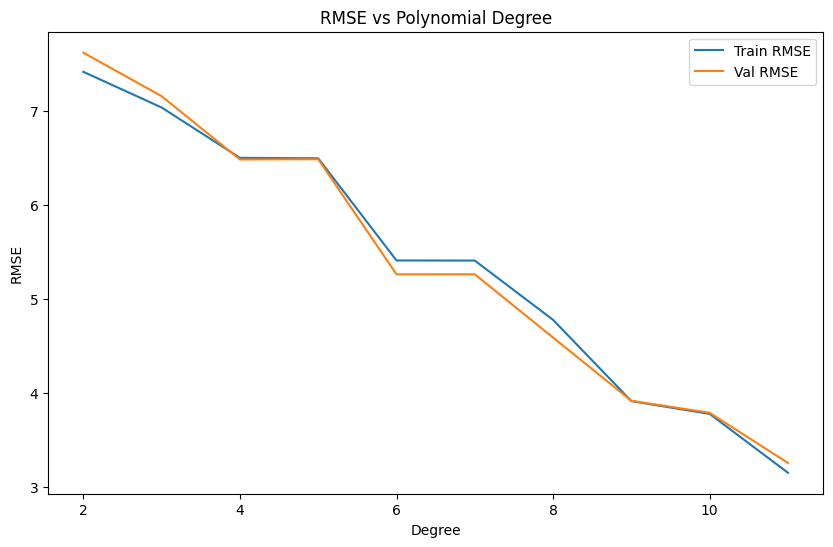

In [44]:

degrees = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
train_rmses = []
val_rmses = []



for p in degrees:
    poly = PolynomialFeatures(degree=p)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    # Train model
    poly_reg = LinearRegression()
    poly_reg.fit(X_train_poly, y_train)

    # Predict and calculate RMSE
    train_rmse = np.sqrt(mean_squared_error(y_train, poly_reg.predict(X_train_poly)))
    val_rmse = np.sqrt(mean_squared_error(y_val, poly_reg.predict(X_val_poly)))
    train_rmses.append(train_rmse)
    val_rmses.append(val_rmse)
    
   
    if p :
        plt.figure(figsize=(10, 6))
        plt.scatter(X_train, y_train, label="Training Data")
        plt.scatter(X_val, y_val, label="Validation Data")
        
        
        X_plot = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
        X_plot_poly = poly.transform(X_plot)
        plt.plot(X_plot, poly_reg.predict(X_plot_poly), color='red', label=f'Degree {p} Fit')
        
        plt.title(f"Polynomial Regression (Degree {p})")
        plt.legend()
        plt.show()


plt.figure(figsize=(10, 6))
plt.plot(degrees, train_rmses, label="Train RMSE")
plt.plot(degrees, val_rmses, label="Val RMSE")
plt.xlabel("Degree")
plt.ylabel("RMSE")
plt.legend()
plt.title("RMSE vs Polynomial Degree")
plt.show()


In [47]:
print("trainrms=",train_rmses)

print("valrmse= ",val_rmses)

trainrms= [7.418650976541455, 7.039011787759269, 6.503619002191021, 6.498722818170376, 5.411780072733706, 5.410714993433388, 4.780072288896963, 3.9153750434238996, 3.779506842062592, 3.153717347262545]
valrmse=  [7.621966291632655, 7.159078407137189, 6.486388840932945, 6.489050904489527, 5.264245730700341, 5.264617610856118, 4.591581858601006, 3.9193166622128537, 3.7913561742992874, 3.25809674890879]


In [48]:
val_rmse.min()

3.25809674890879

In [ ]:
#lowest val rmse is for p=11

In [51]:
best_degree = degrees[np.argmin(val_rmses)]
print("best degree" ,best_degree)

best degree 11


In [53]:
poly = PolynomialFeatures(degree=p)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
final_reg = LinearRegression()
final_reg.fit(X_train_poly, y_train)

test_pred= final_reg.predict(X_test_poly)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

In [54]:
print(test_rmse)

2.8123450962124417


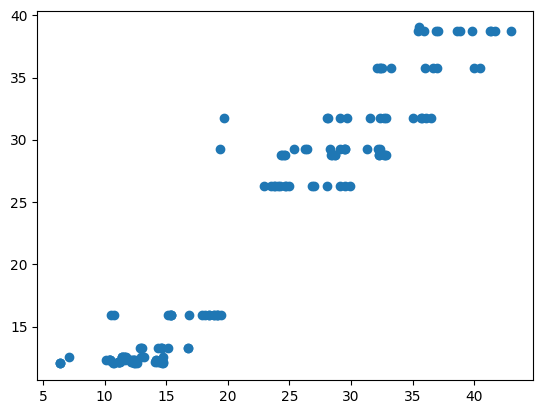

In [56]:
plt.scatter( y_test, test_pred , label ="Actual vs Predicted Heating Load on the test data for the best polynomial model")

In [49]:
#multiple linear regression

In [63]:


X_train_mlr = train_df[["X1" , "X2" , "X3" , "X4" , "X5" , "X6" , "X7" , "X8" , "X9" ]]
y_train_mlr = train_df ["Y"]

X_val_mlr = val_df[["X1" , "X2" , "X3" , "X4" , "X5" , "X6" , "X7" , "X8" , "X9"]]
y_val_mlr = val_df ["Y"]

X_test_mlr = test_df[["X1" , "X2" , "X3" , "X4" , "X5" , "X6" , "X7" , "X8" , "X9"]]
y_test_mlr = test_df ["Y"]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


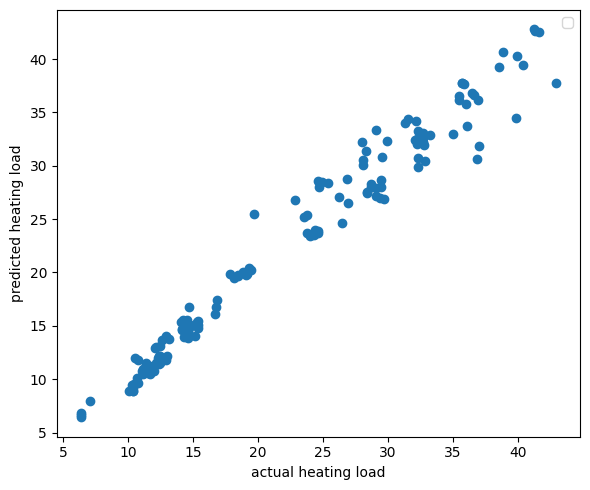

In [97]:
model_mlr= LinearRegression ()
model_mlr. fit ( X_train_mlr , y_train )


train_pred_all = model_mlr.predict(X_train_mlr)
test_pred_all = model_mlr.predict(X_test_mlr)
val_pred_all = model_mlr.predict(X_val_mlr)

rmse_train_all = np . sqrt ( mean_squared_error ( y_train , train_pred_all ) )
rmse_val_all = np . sqrt ( mean_squared_error ( y_val , val_pred_all ) )
rmse_test_all = np . sqrt ( mean_squared_error ( y_test , test_pred_all ) )



plt.figure(figsize=(6,5))
plt.scatter(y_test,test_pred_all)
plt.xlabel('actual heating load')
plt.ylabel('predicted heating load')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
##correlation

In [74]:
correlations = train_df . corr () ['Y']. drop ('Y')

x_best= correlations.abs().idxmax ()
#print ( " Feature with highest absolute correlation : { x_best } ".format(x_best=x_best) )
print(x_best)

X_train = train_df[[x_best]]
y_train = train_df ["Y"]

X_val = val_df[[x_best]]
y_val = val_df ["Y"]

X_test = test_df[[x_best]]
y_test = test_df ["Y"]

X9


In [75]:
lin_reg = LinearRegression ()
lin_reg . fit ( X_train , y_train )
# Generate predictions
y_train_pred = lin_reg . predict ( X_train )
y_val_pred = lin_reg . predict ( X_val )
y_test_pred = lin_reg . predict ( X_test )
rmse_train = np . sqrt ( mean_squared_error ( y_train , y_train_pred ) )
rmse_val = np . sqrt ( mean_squared_error ( y_val , y_val_pred ) )
rmse_test = np . sqrt ( mean_squared_error ( y_test , y_test_pred ) )
print("Train RMSE : {rmse_train:.4f} | Val RMSE : {rmse_val:.4f}| Test RMSE : {rmse_test:.4f}".format(rmse_train=rmse_train, rmse_val=rmse_val, rmse_test=rmse_test))


Train RMSE : 2.1536 | Val RMSE : 2.3382| Test RMSE : 2.2067


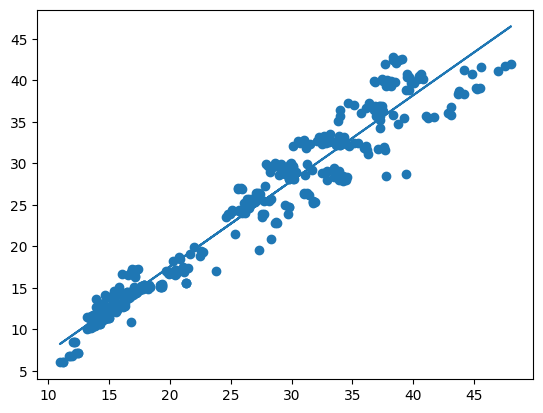

In [76]:
plt.scatter( X_train , y_train , label ="trining data")
plt.plot(X_train , y_train_pred)


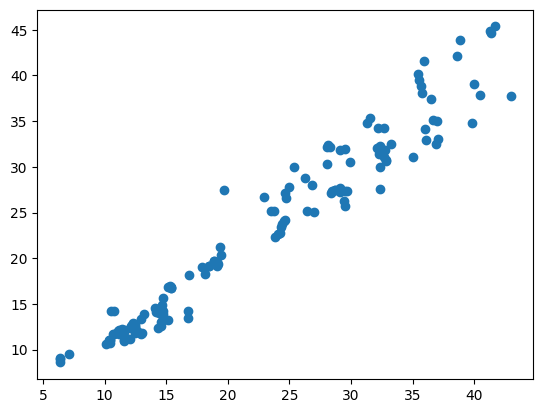

In [77]:
plt.scatter( y_test, y_test_pred , label ="training data")

In [ ]:
#polynomial correlated

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


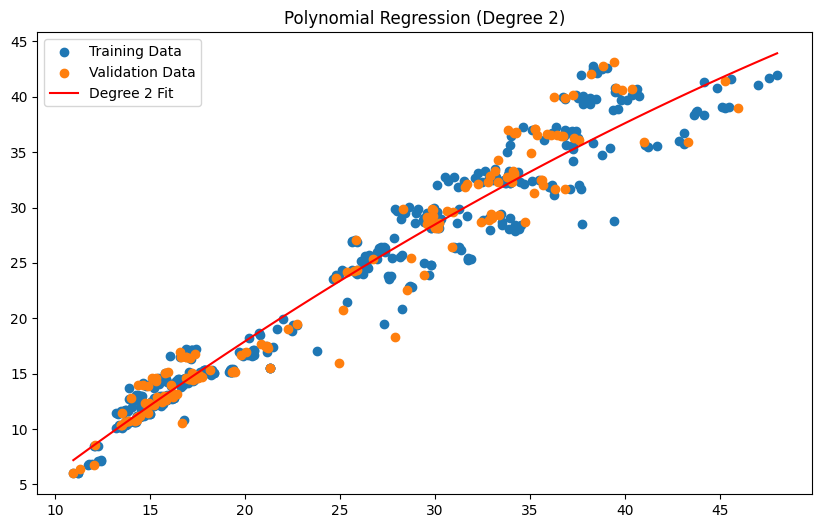

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


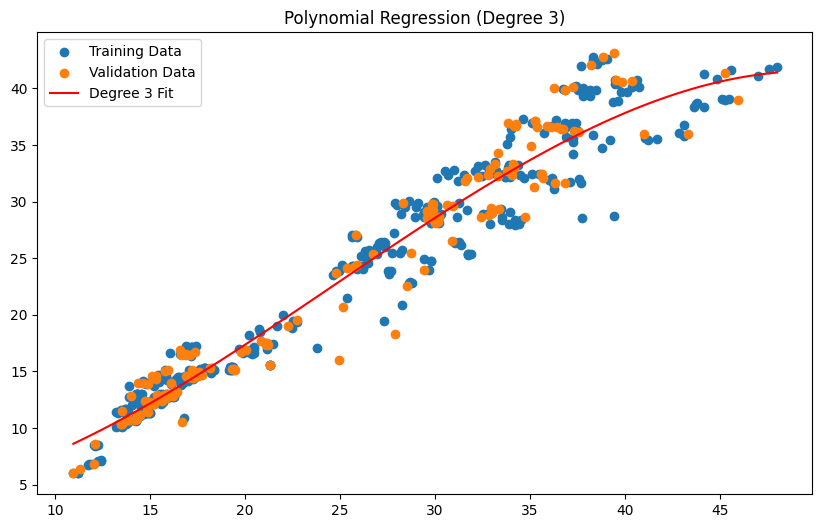

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


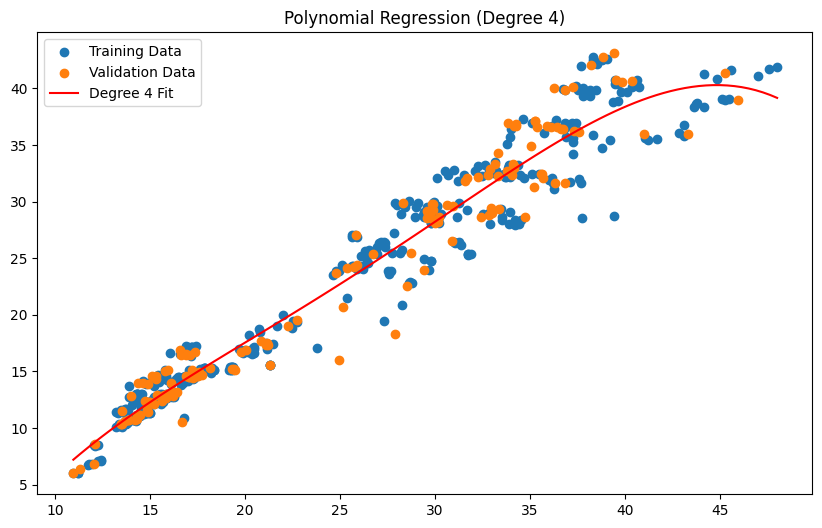

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


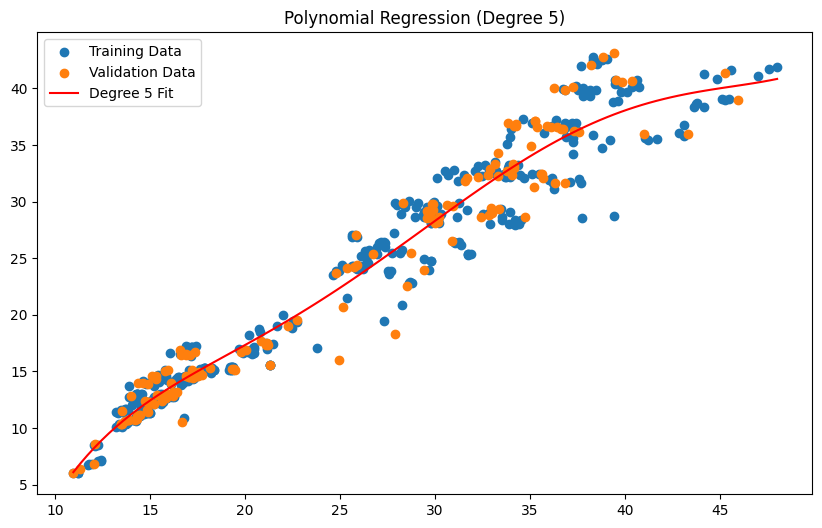

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


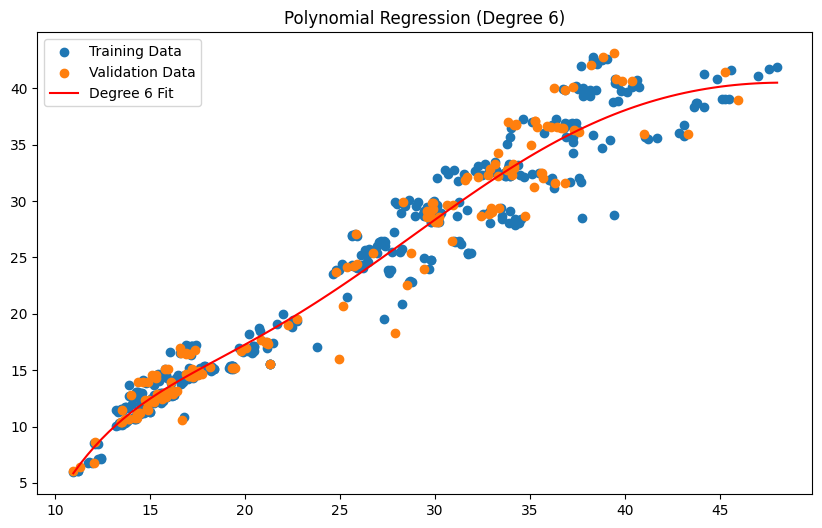

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


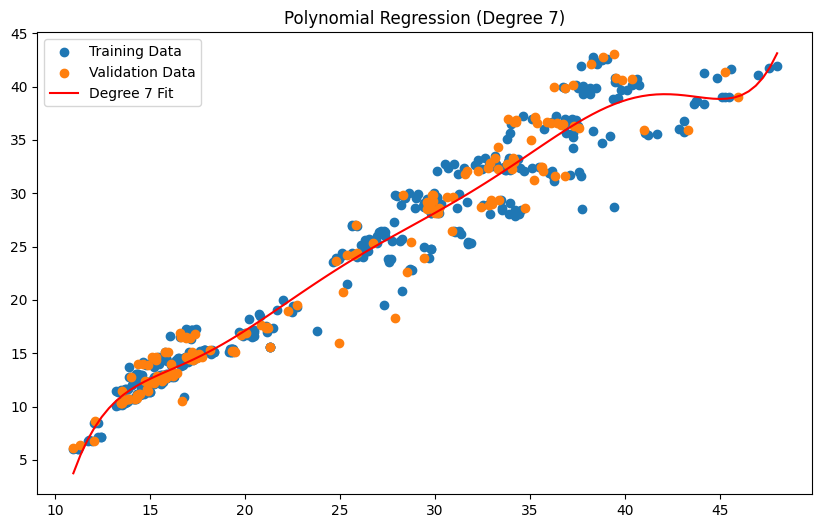

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


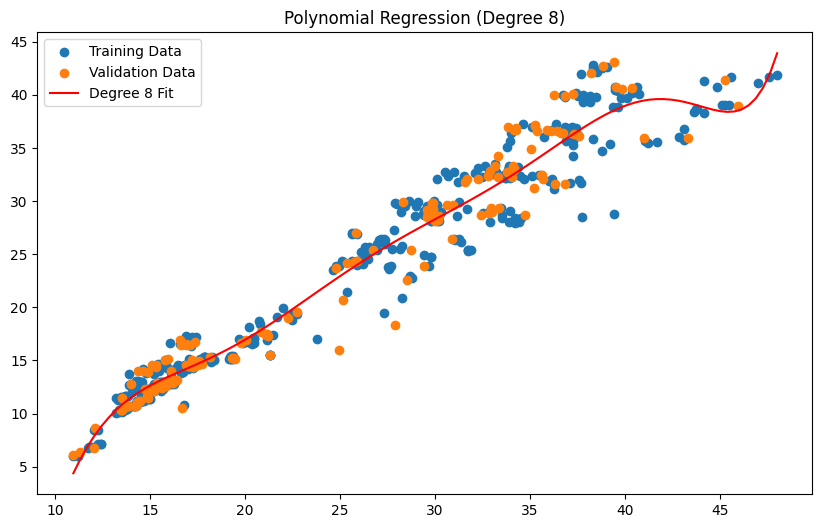

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


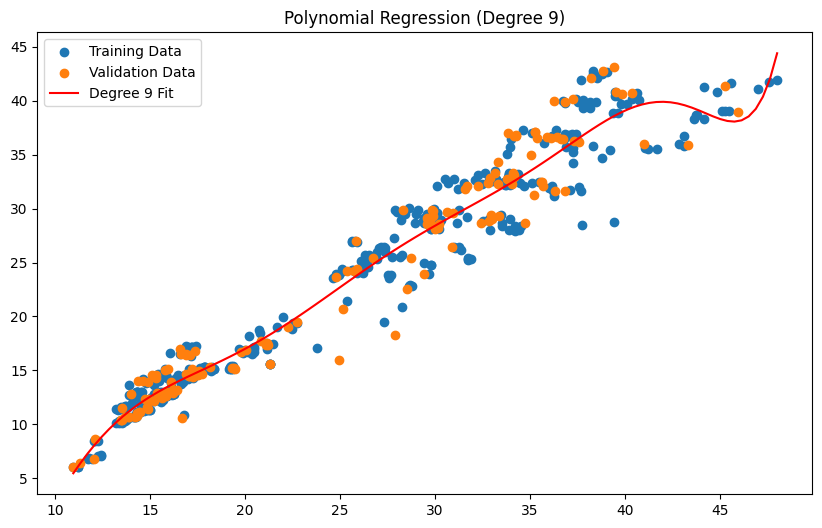

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


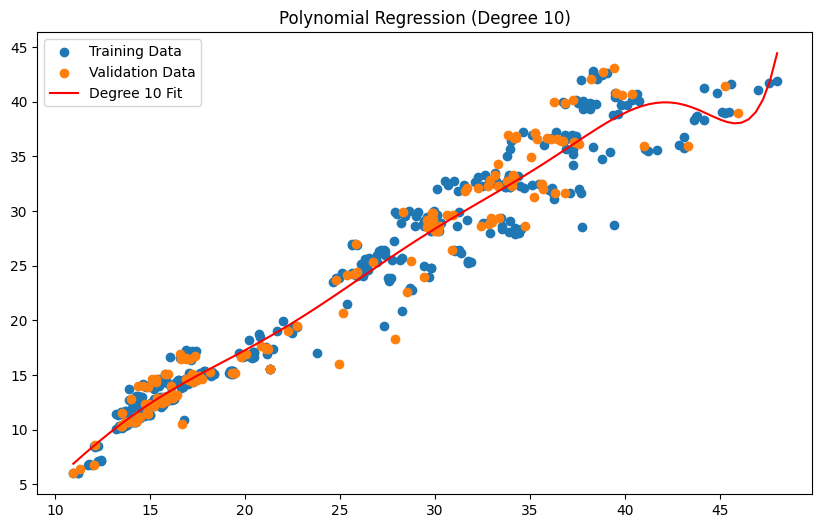

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


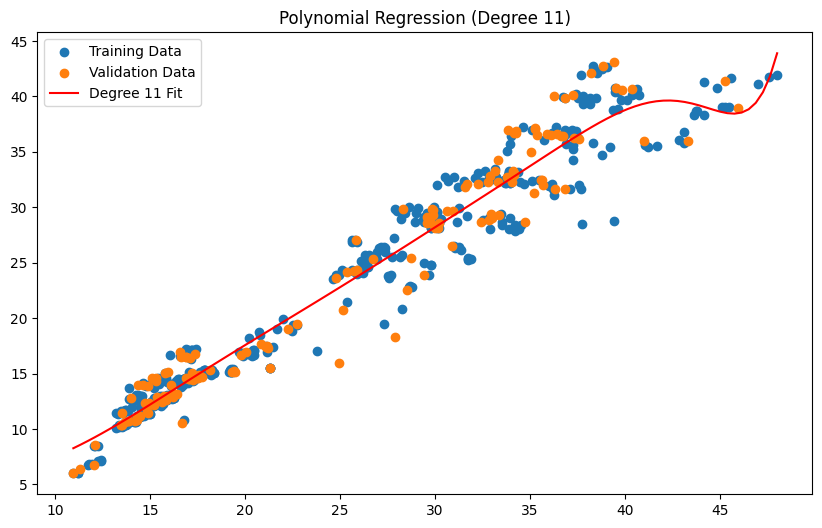

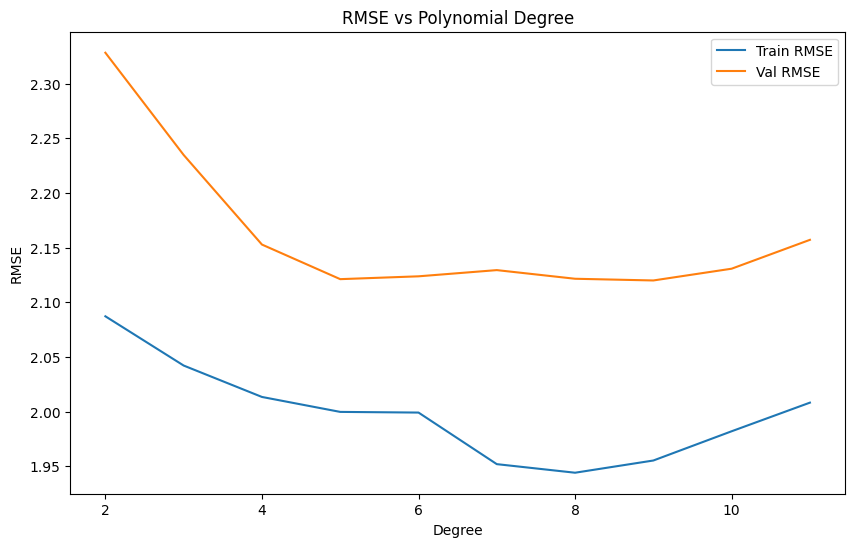

In [78]:

degrees = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
train_rmses = []
val_rmses = []



for p in degrees:
    poly = PolynomialFeatures(degree=p)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    # Train model
    poly_reg = LinearRegression()
    poly_reg.fit(X_train_poly, y_train)

    # Predict and calculate RMSE
    train_rmse = np.sqrt(mean_squared_error(y_train, poly_reg.predict(X_train_poly)))
    val_rmse = np.sqrt(mean_squared_error(y_val, poly_reg.predict(X_val_poly)))
    train_rmses.append(train_rmse)
    val_rmses.append(val_rmse)
    
   
    if p :
        plt.figure(figsize=(10, 6))
        plt.scatter(X_train, y_train, label="Training Data")
        plt.scatter(X_val, y_val, label="Validation Data")
        
        
        X_plot = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
        X_plot_poly = poly.transform(X_plot)
        plt.plot(X_plot, poly_reg.predict(X_plot_poly), color='red', label=f'Degree {p} Fit')
        
        plt.title(f"Polynomial Regression (Degree {p})")
        plt.legend()
        plt.show()


plt.figure(figsize=(10, 6))
plt.plot(degrees, train_rmses, label="Train RMSE")
plt.plot(degrees, val_rmses, label="Val RMSE")
plt.xlabel("Degree")
plt.ylabel("RMSE")
plt.legend()
plt.title("RMSE vs Polynomial Degree")
plt.show()


In [79]:
print("trainrms=",train_rmses)

print("valrmse= ",val_rmses)

trainrms= [2.087231197598807, 2.0422019315179654, 2.0134725630665535, 1.9998016633656577, 1.9991929609256458, 1.9520211905895366, 1.9441769178242225, 1.9553486500376152, 1.9820961572434486, 2.008273757325102]
valrmse=  [2.328296197918854, 2.2347852902626597, 2.152852776617449, 2.121209654231319, 2.123802103216902, 2.1294777327303405, 2.1215704926100796, 2.12000899487516, 2.1307688460441545, 2.1571712631742663]


In [80]:
val_rmse.min()

2.1571712631742663

In [81]:
best_degree = degrees[np.argmin(val_rmses)]
print("best degree" ,best_degree)

best degree 9


In [82]:
poly = PolynomialFeatures(degree=p)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
final_reg = LinearRegression()
final_reg.fit(X_train_poly, y_train)

test_pred= final_reg.predict(X_test_poly)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

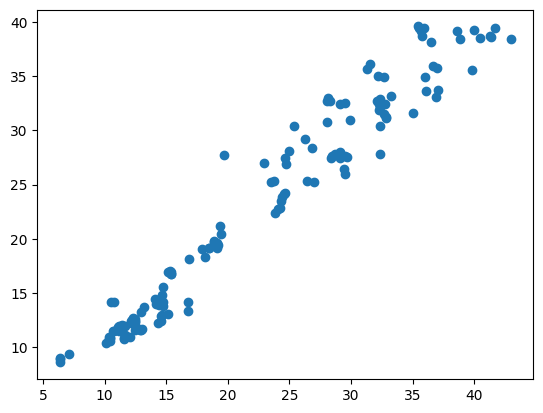

In [83]:
plt.scatter( y_test, test_pred , label ="Actual vs Predicted Heating Load on the test data for the best polynomial model")

In [ ]:
#multiple 

In [84]:
top2 = correlations.abs().nlargest(2).index.tolist()
print(top2)

['X9', 'X5']


In [87]:
X_train_2d = train_df[top2]
X_val_2d = val_df[top2]
X_test_2d = test_df[top2]


/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


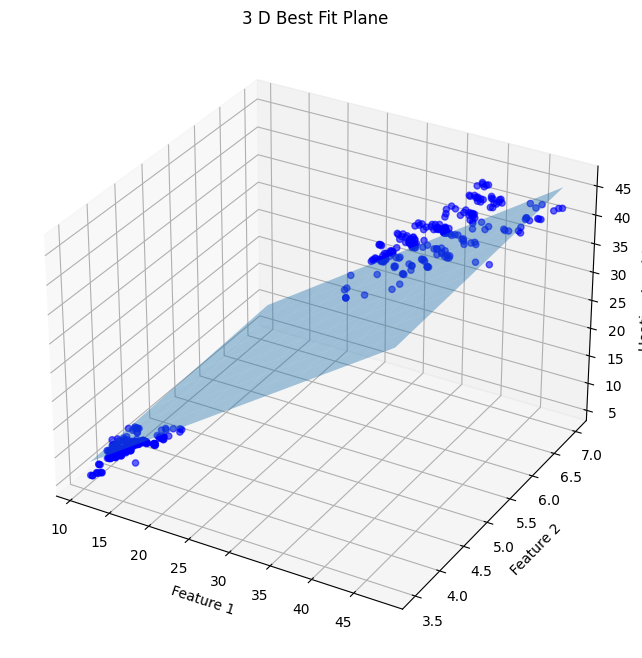

rmse_test_2d


In [95]:
model_2d = LinearRegression ()
model_2d . fit ( X_train_2d , y_train )
fig = plt . figure ( figsize =(10 , 8) )
ax = fig . add_subplot (111 , projection = '3d')

feat1 = X_train_2d . iloc [: , 0]
feat2 = X_train_2d . iloc [: , 1]
ax . scatter ( feat1 , feat2 , y_train , color = 'blue' , alpha =0.6 ,label = ' Actual Data ')

x1_range = np . linspace ( feat1 . min () , feat1 . max () , 10)
x2_range = np . linspace ( feat2 . min () , feat2 . max () , 10)
xx1 , xx2 = np . meshgrid ( x1_range , x2_range )

grid_points = np . c_ [ xx1 . ravel () , xx2 . ravel () ]

 # Predict Z values ( Heating Load ) for the plane and reshape
zz = model_2d . predict ( grid_points ) . reshape ( xx1 . shape )

ax . plot_surface ( xx1 , xx2 , zz , alpha =0.4)

ax . set_xlabel ( ' Feature 1 ')
ax . set_ylabel ( ' Feature 2 ')
ax . set_zlabel ( ' Heating Load ( y ) ')
ax . set_title ( '3 D Best Fit Plane ')
plt . show ()
y_test_pred_2d = model_2d . predict ( X_test_2d )
rmse_test_2d = np . sqrt ( mean_squared_error ( y_test ,y_test_pred_2d ) )
print ("rmse_test_2d")

In [98]:
#model comparison

In [103]:
comparison = pd.DataFrame({ 'Model' : [ 'Simple Linear Regression using Relative Compactness (x1)' ,'Best Polynomial Regression Model (selected using validation RMSE)','Simple Linear Regression using the Top Correlated Features','Multiple Linear Regression using the Top Two Correlated Features','Multiple Linear Regression using All Input Features'],
                           'Test RMSE ' : [ round(rmse_test , 4 ),
                                            round(test_rmse , 4 ) ,
                                            round(test_rmse, 4 ),
                                            round(rmse_test_2d , 4 ) ,
                                            round(rmse_test_all , 4 ) ]
                          })
print(comparison.to_string(index= False))


                                                            Model  Test RMSE 
         Simple Linear Regression using Relative Compactness (x1)      2.2067
Best Polynomial Regression Model (selected using validation RMSE)      2.0965
       Simple Linear Regression using the Top Correlated Features      2.0965
 Multiple Linear Regression using the Top Two Correlated Features      2.1380
              Multiple Linear Regression using All Input Features      1.7119
